# Procesamiento de Imágenes - UNS - Doctorado¶

Trabajo Práctico 3 - Operaciones de Luminancia

In [1]:
# load and display an image with Matplotlib
import os
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.ticker as ticker

from collections import Counter
from skimage.transform import resize
from PIL import Image

from matplotlib.widgets import Slider

# Workflok

1. Normalizar los valores de RGB del pixel
2. RGB -> YIQ {utilizando la matriz correspondiente}
3. Y’ := f(Y); {sqrt() o sqr() según se elija}
4. Y’IQ -> R’G’B’ {notar que la cromaticidad (IQ) no se altera}
5. Convertir R’G’B’ a bytes y graficar el pixel el pixel

In [2]:
def read_img(path):

    name = os.path.basename(path)

    rename, ext = os.path.splitext(name)

    img = mpimg.imread(path)

    if img.shape[1] > 800:        
    
        h, w = img.shape[:2]
        new_width = 800
        ratio = new_width / w
        new_height = int(h * ratio)

        image_resized = resize(
            img,
            (new_height, new_width),
            preserve_range=True,
            anti_aliasing=True
        ).astype(img.dtype)

        mpimg.imsave(
            os.path.join(os.getcwd(), "data", f"{rename}_resized{ext}"),
            image_resized
        )

        img = mpimg.imread(os.path.join(os.getcwd(), "data", f"{rename}_resized{ext}"))        

    return img

In [3]:
class WorkflowLuminancia:

    def __init__(self, img, type_lu="low_luminance", output="save.jpg", k=None, x0=None):

        img = np.asarray(img)

        if img.dtype == np.uint8:
            
            self.img = img.astype(np.float32) / 255.0
            
        else:
            
            self.img = img.astype(np.float32)

        self.type_lu = type_lu

        self.output = output

        self.k = k

        self.x0 = x0

    def rgb_to_yiq(self):

        modified_img = np.copy(self.img)            

        height, width, channels = modified_img.shape

        for i in range(height):
    
            for j in range(width):

                r, g, b = modified_img[i, j]

                change_y = 0.299 * r + 0.587 * g + 0.114 * b
                change_i = 0.595716 * r - 0.274453 * g - 0.321263 * b
                change_q = 0.211456 * r - 0.522591 * g + 0.311135 * b

                modified_img[i, j] = [change_y, change_i + 0.5, change_q + 0.5]  
                
        return modified_img
    
    def transform(self):

        modified_img = self.rgb_to_yiq()            

        height, width, channels = modified_img.shape      
        

        if self.type_lu != "lineal_trozos" and self.type_lu != "normalizacion" and  self.type_lu != "ecualizacion":

            for i in range(height):
    
                for j in range(width):

                    y, i_, q = modified_img[i, j]

                    if self.type_lu == "low_luminance":                   

                        change_y = y**(1/2)                    

                    elif self.type_lu == "high_luminance":

                        change_y = y**2

                    modified_img[i, j] = [change_y, i_, q]


        elif self.type_lu == "lineal_trozos":

            y_channel = modified_img[:, :, 0]

            y_min = y_channel.min()
            y_max = y_channel.max()
            
            change_y = np.clip(
                (y_channel - y_min) / (y_max - y_min + 1e-8),
                0.0,
                1.0
            )

            modified_img[:, :, 0] = change_y

        
        elif self.type_lu == "normalizacion":

            y_channel = modified_img[:, :, 0]

            y_min = y_channel.min()
            y_max = y_channel.max()

            y_norm = (y_channel - y_min) / (y_max - y_min)

            x0 = y_norm.mean() if self.x0 is None else self.x0

            change_y = 1 / (1 + np.exp(-self.k * (y_norm - self.x0)))

            modified_img[:, :, 0] = change_y

        elif self.type_lu == "ecualizacion":

            y_channel = modified_img[:, :, 0].astype(np.float32)

            y01 = np.clip(y_channel, 0.0, 1.0)
            
            y_uint8 = (y01 * 255.0 + 0.5).astype(np.uint8)
            
            flattened_data = y_uint8.ravel()
            N = flattened_data.size
            
            hist = np.bincount(flattened_data, minlength=256)
            cdf = np.cumsum(hist)
            
            cdf_nonzero = cdf[cdf > 0]
            if cdf_nonzero.size == 0:
                pass
            else:
                cdf_min = cdf_nonzero.min()
            
                denom = (N - cdf_min)
                if denom <= 0:
                    pass
                else:
                    cdf_eq = (cdf - cdf_min) / denom
                    cdf_eq = np.clip(cdf_eq, 0.0, 1.0)
            
                    # LUT y mapeo
                    lut = (cdf_eq * 255.0 + 0.5).astype(np.uint8)
                    y_eq_uint8 = lut[flattened_data].reshape(y_channel.shape)
            
                    # Volver a [0,1] y asignar en Y
                    modified_img[:, :, 0] = y_eq_uint8.astype(np.float32) / 255.0


        else:

            raise ValueError("Elegir metodo adecuado")                     
                                  
                
        return modified_img

    def yiq_to_rgb(self):

        modified_img = self.transform()

        height, width, channels = modified_img.shape

        for a in range(height):
    
            for b in range(width):
                
                y, i, q = modified_img[a, b]
        
                i -= 0.5
                q -= 0.5
        
                change_r = y + 0.9663 * i + 0.6210 * q
        
                change_g = y - 0.2721 * i - 0.6474 * q
        
                change_b = y - 1.1070 * i + 1.7046 * q        
                
                modified_img[a, b] = [change_r, change_g, change_b]
                
        return np.clip(modified_img, 0.0, 1.0)

    def show_save_image(self):

        modified_img = self.yiq_to_rgb()

        plt.imshow(modified_img)
        plt.axis("off")
        plt.show()

        if not os.path.exists(os.path.join(os.getcwd(), "new")):
            os.makedirs(os.path.join(os.getcwd(), "new"))

        out = (np.clip(modified_img, 0.0, 1.0) * 255).astype(np.uint8)
        mpimg.imsave(os.path.join(os.getcwd(), "new", self.output), out)  

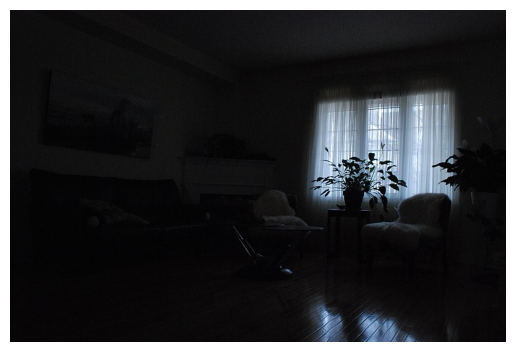

In [4]:
# load image as pixel array
# An image of a file opens
path1 = os.path.join(os.getcwd(), "data", "low_luminance.jpg")
image = read_img(path1)

plt.imshow(image)
plt.axis('off')  # Para desactivar los ejes en la visualización
plt.show()

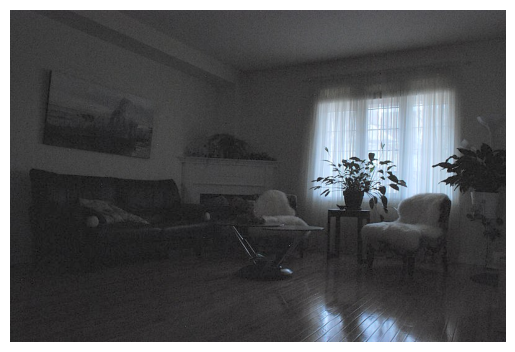

In [5]:
lum = WorkflowLuminancia(image, "low_luminance", "low_m_luminance.png").show_save_image()

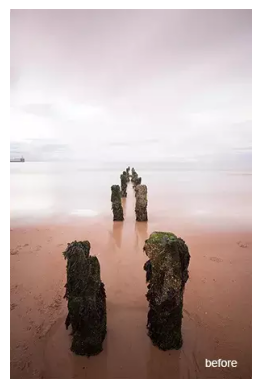

In [6]:
# load image as pixel array
# An image of a file opens
path2 = os.path.join(os.getcwd(), "data", "high_luminance.jpg")
image2 = read_img(path2)

plt.imshow(image2)
plt.axis('off')  # Para desactivar los ejes en la visualización
plt.show()

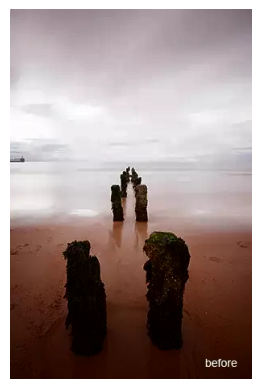

In [7]:
lum2 = WorkflowLuminancia(image2, "high_luminance", "high_m_luminance.png").show_save_image()

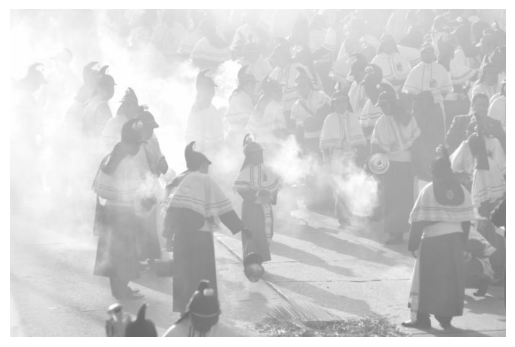

In [8]:
# load image as pixel array
# An image of a file opens
path3 = os.path.join(os.getcwd(), "data", "poco_contraste.jpg")
image3 = read_img(path3)

plt.imshow(image3)
plt.axis('off')  # Para desactivar los ejes en la visualización
plt.show()

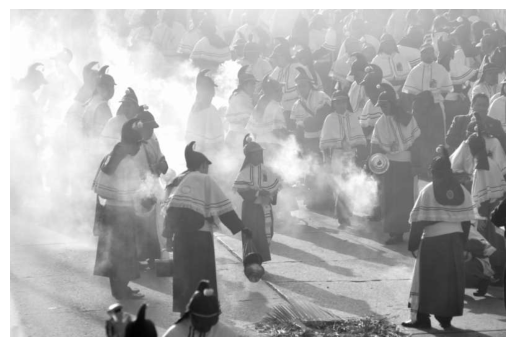

In [9]:
lum3 = WorkflowLuminancia(image3, "lineal_trozos", "poco_m_contraste.png").show_save_image()

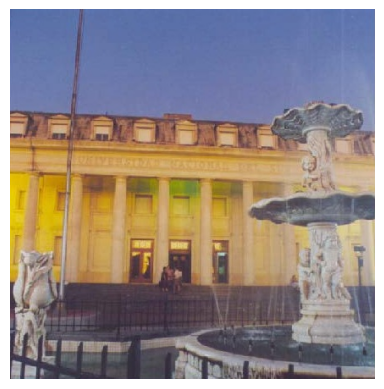

In [10]:
# load image as pixel array
# An image of a file opens
path4 = os.path.join(os.getcwd(), "data", "mal_contraste.jpg")
image4 = read_img(path4)

plt.imshow(image4)
plt.axis('off')  # Para desactivar los ejes en la visualización
plt.show()

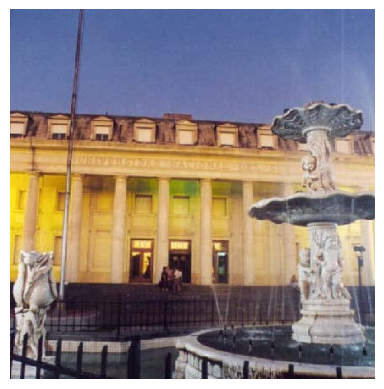

In [11]:
lum4 = WorkflowLuminancia(image4, "lineal_trozos", "mal_m_contraste.png").show_save_image()

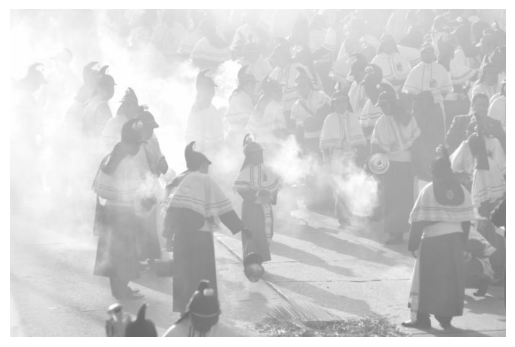

In [12]:
# load image as pixel array
# An image of a file opens
path5 = os.path.join(os.getcwd(), "data", "poco_contraste.jpg")
image5 = read_img(path5)

plt.imshow(image5)
plt.axis('off')  # Para desactivar los ejes en la visualización
plt.show()

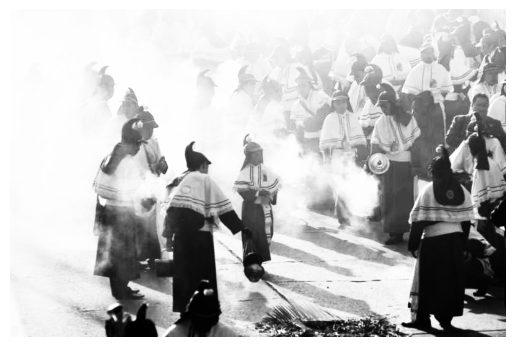

In [13]:
lum5 = WorkflowLuminancia(image5, "normalizacion", "mal_mm_contraste.png", k=12, x0=0.5).show_save_image()

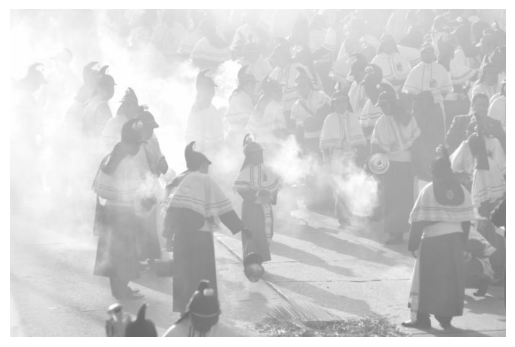

In [14]:
# load image as pixel array
# An image of a file opens
path6 = os.path.join(os.getcwd(), "data", "poco_contraste.jpg")
image6 = read_img(path6)

plt.imshow(image5)
plt.axis('off')  # Para desactivar los ejes en la visualización
plt.show()

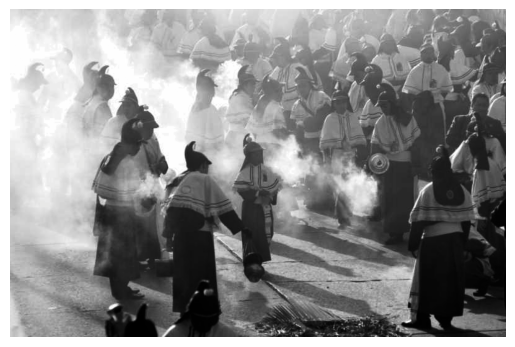

In [15]:
lum6 = WorkflowLuminancia(image5, "ecualizacion", "mal_ee_contraste.png").show_save_image()